In [1]:
#importing

import pandas as pd
import numpy as np
import seaborn as sns
import statistics
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from IPython.display import Image, display
from io import StringIO
from sklearn.tree import export_graphviz
import pydot

df = pd.read_csv("QCAnomalyTrainingData.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ANALYTICAL_TYPE                 99999 non-null  object 
 1   STD_LOT_CODE                    99999 non-null  object 
 2   STD_CODE                        99999 non-null  object 
 3   JOB_CODE                        99999 non-null  object 
 4   NUMERIC_FINAL_VALUE             99999 non-null  float64
 5   ANALYSED_DATE                   99999 non-null  object 
 6   SCHEME_CODE                     99999 non-null  object 
 7   ANALYTE_CODE                    98871 non-null  object 
 8   STANDARD_STATUS                 54675 non-null  object 
 9   PRECISION_STATUS                45315 non-null  object 
 10  INTERNAL_MIN_VALUE              54447 non-null  float64
 11  INTERNAL_MAX_VALUE              54447 non-null  float64
 12  INTERNAL_MIN_INCLUSIVE          

C:\Users\jknig\AppData\Local\Temp\ipykernel_43704\3781040326.py:15: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("QCAnomalyTrainingData.csv")


In [2]:
num_col = df.select_dtypes(include=['number'])
correlation_matrix = num_col.corr()
correlation_matrix

,NUMERIC_FINAL_VALUE,INTERNAL_MIN_VALUE,INTERNAL_MAX_VALUE,INTERNAL_MAX_WARNING_VALUE,INTERNAL_MIN_WARNING_VALUE,LIM_REP_VALUE,STAT_DL_VALUE,LIM_REP_DUP_VALUE,STAT_DL_DUP_VALUE,INTERNAL_TARGET_VALUE,PARENT_NUMERIC_FINAL_VALUE
NUMERIC_FINAL_VALUE,1.000000,0.971917,0.971910,0.971829,0.971832,-0.014033,-0.007624,-0.012435,-0.007594,0.854144,0.998033
INTERNAL_MIN_VALUE,0.971917,1.000000,0.999999,1.000000,1.000000,-0.017727,0.000561,-0.015824,0.000603,0.881030,NaN
INTERNAL_MAX_VALUE,0.971910,0.999999,1.000000,1.000000,1.000000,-0.017820,0.001642,-0.015989,0.001685,0.881020,NaN
INTERNAL_MAX_WARNING_VALUE,0.971829,1.000000,1.000000,1.000000,1.000000,-0.021773,0.000713,-0.019438,0.000764,0.880619,NaN
INTERNAL_MIN_WARNING_VALUE,0.971832,1.000000,1.000000,1.000000,1.000000,-0.021725,0.000254,-0.019383,0.000304,0.880622,NaN
LIM_REP_VALUE,-0.014033,-0.017727,-0.017820,-0.021773,-0.021725,1.000000,-0.105017,0.863807,-0.104899,-0.019098,-0.010001
STAT_DL_VALUE,-0.007624,0.000561,0.001642,0.000713,0.000254,-0.105017,1.000000,-0.105292,0.999863,0.002393,-0.015039
LIM_REP_DUP_VALUE,-0.012435,-0.015824,-0.015989,-0.019438,-0.019383,0.863807,-0.105292,1.000000,-0.105188,-0.017104,-0.008772
STAT_DL_DUP_VALUE,-0.007594,0.000603,0.001685,0.000764,0.000304,-0.104899,0.999863,-0.105188,1.000000,0.002438,-0.015019
INTERNAL_TARGET_VALUE,0.854144,0.881030,0.881020,0.880619,0.880622,-0.019098,0.002393,-0.017104,0.002438,1.000000,NaN


In [3]:
df = df[df['ANALYTICAL_TYPE'] == 'Blank']

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17997 entries, 6 to 99998
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ANALYTICAL_TYPE                 17997 non-null  object 
 1   STD_LOT_CODE                    17997 non-null  object 
 2   STD_CODE                        17997 non-null  object 
 3   JOB_CODE                        17997 non-null  object 
 4   NUMERIC_FINAL_VALUE             17997 non-null  float64
 5   ANALYSED_DATE                   17997 non-null  object 
 6   SCHEME_CODE                     17997 non-null  object 
 7   ANALYTE_CODE                    17831 non-null  object 
 8   STANDARD_STATUS                 17993 non-null  object 
 9   PRECISION_STATUS                0 non-null      object 
 10  INTERNAL_MIN_VALUE              17997 non-null  float64
 11  INTERNAL_MAX_VALUE              17997 non-null  float64
 12  INTERNAL_MIN_INCLUSIVE          17997

In [4]:
#Dropping columns and filtering
filtered_df = df.drop(['UNIT_CODE', 'SPECIFICATION_CODE', 'PARENT_NUMERIC_FINAL_VALUE', 'INSTRUMENT_ID', 'INTERNAL_MAX_WARNING_VALUE', 'INTERNAL_MIN_WARNING_VALUE', 'PRECISION_STATUS', 'STD_LOT_CODE', 'STD_CODE'], axis=1, inplace=False)

filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17997 entries, 6 to 99998
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ANALYTICAL_TYPE                 17997 non-null  object 
 1   JOB_CODE                        17997 non-null  object 
 2   NUMERIC_FINAL_VALUE             17997 non-null  float64
 3   ANALYSED_DATE                   17997 non-null  object 
 4   SCHEME_CODE                     17997 non-null  object 
 5   ANALYTE_CODE                    17831 non-null  object 
 6   STANDARD_STATUS                 17993 non-null  object 
 7   INTERNAL_MIN_VALUE              17997 non-null  float64
 8   INTERNAL_MAX_VALUE              17997 non-null  float64
 9   INTERNAL_MIN_INCLUSIVE          17997 non-null  object 
 10  INTERNAL_MAX_INCLUSIVE          17997 non-null  object 
 11  INTERNAL_MIN_WARNING_INCLUSIVE  17997 non-null  object 
 12  INTERNAL_MAX_WARNING_INCLUSIVE  17997

In [5]:
filtered_df.value_counts()

ANALYTICAL_TYPE  JOB_CODE          NUMERIC_FINAL_VALUE  ANALYSED_DATE  SCHEME_CODE  ANALYTE_CODE  STANDARD_STATUS  INTERNAL_MIN_VALUE  INTERNAL_MAX_VALUE  INTERNAL_MIN_INCLUSIVE  INTERNAL_MAX_INCLUSIVE  INTERNAL_MIN_WARNING_INCLUSIVE  INTERNAL_MAX_WARNING_INCLUSIVE  LIM_REP_VALUE  STAT_DL_VALUE  LIM_REP_DUP_VALUE  STAT_DL_DUP_VALUE  INTERNAL_TARGET_VALUE
Blank            TSV_LB0003795557  0.009000             51:13.0        GE_IMS40Q12  W             Pass             -0.250              0.250               Y                       Y                       Y                               Y                               15             0.250          22.5               0.250              0.0                      2
                 TSV_LB0002670477  0.008800             12:47.0        GE_IMS40Q12  TE            Pass             -0.500              0.500               Y                       Y                       Y                               Y                               10            

In [6]:
# importing
import matplotlib.pyplot as plt
import seaborn as sns

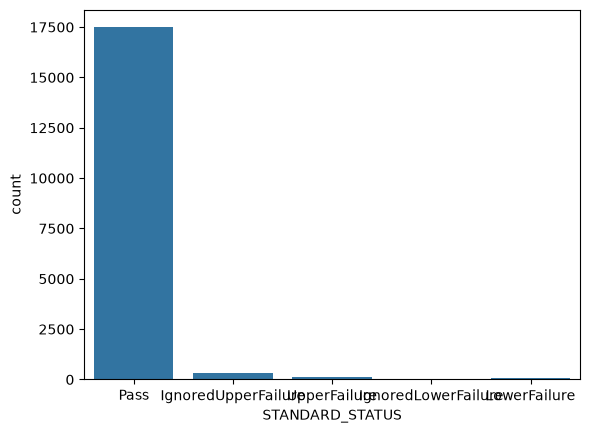

In [7]:
dg = sns.countplot(data=filtered_df, x='STANDARD_STATUS')
plt.show()

<Axes: xlabel='ANALYSED_DATE'>

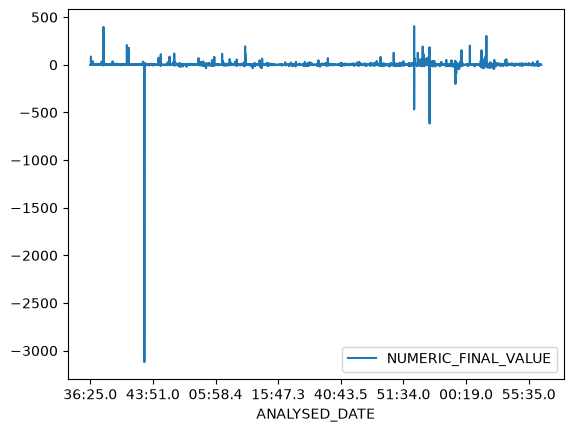

In [8]:
filtered_df.plot(x='ANALYSED_DATE', y='NUMERIC_FINAL_VALUE')

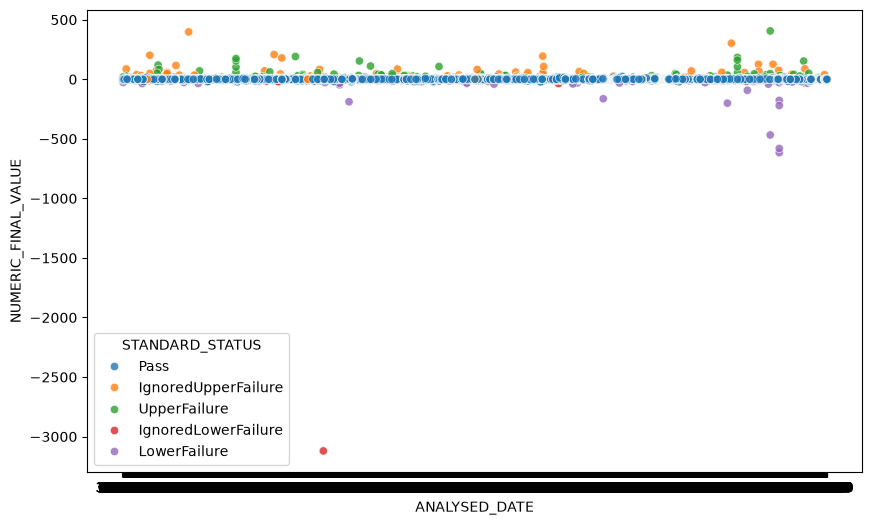

In [9]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=filtered_df, 
    x='ANALYSED_DATE', 
    y='NUMERIC_FINAL_VALUE', 
    hue='STANDARD_STATUS',
    alpha=0.8
)
plt.show()

## CREATING A TEST/TRAIN PARTITION

In [10]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17997 entries, 6 to 99998
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ANALYTICAL_TYPE                 17997 non-null  object 
 1   JOB_CODE                        17997 non-null  object 
 2   NUMERIC_FINAL_VALUE             17997 non-null  float64
 3   ANALYSED_DATE                   17997 non-null  object 
 4   SCHEME_CODE                     17997 non-null  object 
 5   ANALYTE_CODE                    17831 non-null  object 
 6   STANDARD_STATUS                 17993 non-null  object 
 7   INTERNAL_MIN_VALUE              17997 non-null  float64
 8   INTERNAL_MAX_VALUE              17997 non-null  float64
 9   INTERNAL_MIN_INCLUSIVE          17997 non-null  object 
 10  INTERNAL_MAX_INCLUSIVE          17997 non-null  object 
 11  INTERNAL_MIN_WARNING_INCLUSIVE  17997 non-null  object 
 12  INTERNAL_MAX_WARNING_INCLUSIVE  17997

In [11]:
filtered_df['STANDARD_STATUS'] = filtered_df['STANDARD_STATUS'].fillna(statistics.mode(filtered_df['STANDARD_STATUS']))
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17997 entries, 6 to 99998
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ANALYTICAL_TYPE                 17997 non-null  object 
 1   JOB_CODE                        17997 non-null  object 
 2   NUMERIC_FINAL_VALUE             17997 non-null  float64
 3   ANALYSED_DATE                   17997 non-null  object 
 4   SCHEME_CODE                     17997 non-null  object 
 5   ANALYTE_CODE                    17831 non-null  object 
 6   STANDARD_STATUS                 17997 non-null  object 
 7   INTERNAL_MIN_VALUE              17997 non-null  float64
 8   INTERNAL_MAX_VALUE              17997 non-null  float64
 9   INTERNAL_MIN_INCLUSIVE          17997 non-null  object 
 10  INTERNAL_MAX_INCLUSIVE          17997 non-null  object 
 11  INTERNAL_MIN_WARNING_INCLUSIVE  17997 non-null  object 
 12  INTERNAL_MAX_WARNING_INCLUSIVE  17997

In [12]:
filtered_df.info()

Y = filtered_df["STANDARD_STATUS"]
X = filtered_df.drop(["STANDARD_STATUS"], axis=1)
X = pd.get_dummies(filtered_df)
feature_names = X.columns



# splitting 

random_state = 10
test_set_size = 0.3 # doing a 30/70 split

X_train, X_test, y_train, y_test = train_test_split(X.values, Y, test_size=test_set_size, stratify=Y, random_state=random_state)

print("Size of training set:", len(X_train))
print("Size of testing set:", len(X_test))

<class 'pandas.core.frame.DataFrame'>
Index: 17997 entries, 6 to 99998
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ANALYTICAL_TYPE                 17997 non-null  object 
 1   JOB_CODE                        17997 non-null  object 
 2   NUMERIC_FINAL_VALUE             17997 non-null  float64
 3   ANALYSED_DATE                   17997 non-null  object 
 4   SCHEME_CODE                     17997 non-null  object 
 5   ANALYTE_CODE                    17831 non-null  object 
 6   STANDARD_STATUS                 17997 non-null  object 
 7   INTERNAL_MIN_VALUE              17997 non-null  float64
 8   INTERNAL_MAX_VALUE              17997 non-null  float64
 9   INTERNAL_MIN_INCLUSIVE          17997 non-null  object 
 10  INTERNAL_MAX_INCLUSIVE          17997 non-null  object 
 11  INTERNAL_MIN_WARNING_INCLUSIVE  17997 non-null  object 
 12  INTERNAL_MAX_WARNING_INCLUSIVE  17997

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

print("Bf Scaling\n-=-=-=-=-=-=-")


for i in range(5):
    col = X_train[:,i]
    print("Variable #{}: min {}, max {}, mean {:.2f} and std dev {:.2f}".format(i, min(col), max(col), np.mean(col), np.std(col)))

X_train = scaler.fit_transform (X_train, y_train)

print("Af Scaling\n-=-=-=-=-=-=-")

for i in range(5):
    col = X_train[:,i]
    print("Variable #{}: min {}, max {}, mean {:.2f} and std dev {:.2f}".format(i, min(col), max(col), np.mean(col), np.std(col)))

X_test = scaler.transform(X_test)

Bf Scaling
-=-=-=-=-=-=-
Variable #0: min -3120.62395, max 405.93, mean 0.36 and std dev 30.25
Variable #1: min -50.0, max -0.0025, mean -7.04 and std dev 9.72
Variable #2: min 0.0025, max 50.0, mean 7.04 and std dev 9.72
Variable #3: min 10, max 15, mean 10.25 and std dev 1.08
Variable #4: min 0.025, max 50.0, mean 4.03 and std dev 7.03
Af Scaling
-=-=-=-=-=-=-
Variable #0: min -103.17314603783564, max 13.407137677455122, mean 0.00 and std dev 1.00
Variable #1: min -4.417815300514363, max 0.7233608853239403, mean -0.00 and std dev 1.00
Variable #2: min -0.7233608853239403, max 4.417815300514363, mean 0.00 and std dev 1.00
Variable #3: min -0.22732812512652792, max 4.398927758910407, mean -0.00 and std dev 1.00
Variable #4: min -0.5687398923072458, max 6.535452596164616, mean -0.00 and std dev 1.00


In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=random_state)

model.fit(X_train, y_train)

LogisticRegression(random_state=10)

In [15]:
from sklearn.metrics import classification_report

print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

Train accuracy: 1.0
Test accuracy: 0.9987037037037036
                     precision    recall  f1-score   support

IgnoredLowerFailure       1.00      1.00      1.00        11
IgnoredUpperFailure       0.93      1.00      0.96        92
       LowerFailure       1.00      1.00      1.00        15
               Pass       1.00      1.00      1.00      5246
       UpperFailure       1.00      1.00      1.00        36

           accuracy                           1.00      5400
          macro avg       0.99      1.00      0.99      5400
       weighted avg       1.00      1.00      1.00      5400



In [16]:

filtered_df['Prediction'] = model.predict(filtered_df['STANDARD_STATUS'])






"""
we needed these before so these were snagged from the other notebook.
"""


GROUP_COLUMNS = [
    "SCHEME_CODE",
    "ANALYTE_CODE",
]

filtered_df["TARGET_DEVIATION"] = (
    filtered_df["NUMERIC_FINAL_VALUE"]
    - filtered_df["INTERNAL_FINAL_VALUE"]
)

filtered_df["GROUP_MEDIAN"] = (
    filtered_df.groupby(GROUP_COLUMNS)["NUMERIC_FINAL_VALUE"].transform("median")
)

filtered_df["ABS_MEDIAN_DEVIATION"] = (
    filtered_df["NUMERIC_FINAL_VALUE"]
    - filtered_df["GROUP_MEDIAN"]
).abs()

filtered_df["GROUP_MAD"] = (
    filtered_df.groupby(GROUP_COLUMNS)["ABS_MEDIAN_DEVIATION"].transform("median")
)

# drift report

filtered_df["ROLL_MEDIAN"] = (
    filtered_df.groupby(GROUP_COLUMNS)["NUMERIC_FINAL_VALUE"]
    .transform(
        lambda values: values.rolling(
            window=10,
            min_periods=3
        ).median()
    )
)

filtered_df["ROLLING_CHANGE"] = (
    filtered_df["ROLLING_MEDIAN"]
    - filtered_df["GROUP_MEDIAN"]
)


display(analysis_df.head())


ValueError: could not convert string to float: 'Pass'